# Week 4 Day 5: Capstone
### Ensembles, Imbalance Handling, Interpretability & Deployment
This is the last day of the ML foundations week. Bringing everything together from Day 1 to Day 4, lets do this

### Goal: 
Perform hyperparameter tuning for RandomForest (gotta do this since its a requirement even though it was not one of my top models)

Task 1: Train & Compare Ensemble Models

Task 2: Systematically Address Class Imbalance

Task 3: Interpretability & Fairness Checks

Task 4: End-to-End Inference & Basic Monitoring Plan

Task 5: Make an exective report and a Presentation

### Dataset (same as before)

We are using the Adult Census Income Dataset.

Some stuff we did for day 1:

* 0 = <=50K
* 1 = >50K

## Imports

In [1]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install imblearn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/676.6 kB ? eta -:--:--
   ------------------------------ --------- 524.3/676.6 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 676.6/676.6 kB 2.1 MB/s  0:00:00
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
    --------------------------------------- 1.0/43.0 MB 5.6 MB/s eta 0:00:08
   - -------------------------------------- 1.8/43.0 MB 4.6 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/43.0 MB 4.3 MB/s eta 0:00:10
   --- ------------------------------------ 3.4/43.0 MB 4.0 MB/s eta 0:00:10
   ---- ----------------------------------- 4.5/43.0 MB 4.2 MB/s eta 0:00:10
   ----- ---------------------------------- 5.8/43.0 MB 4.5 MB/s eta 0:00:09
   ------ --------------------------------- 7.1/43.0 MB 4.7 MB/s eta 0:00:08
   ------- -------------------------------- 8.1/43.0 MB 4.8 MB/s eta 0:00:08
   -----

In [152]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.datasets import fetch_openml


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression  #need this for the bonus challenge of stacking ensemble (this will be our meta model)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate

import shap
RANDOM_STATE = 42
CHOSEN_THRESHOLD = 0.60

In [9]:
adult = fetch_openml(
    name="adult",
    version=2,              #apparently the second version doesnt have any ? so thats why i wasnt able to "clean" that
    as_frame=True
)

df = adult.frame.copy()
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


## Basic Cleaning

In [10]:
df.rename(columns={"class": "income"}, inplace=True)
df.columns
df["income"] = df["income"].map({"<=50K" : 0, ">50K" : 1})   #mapping it just like day1


In [13]:
### Splitting from Day 1
X = df.drop("income", axis=1)
y = df["income"]

# Dropping columns that we wont need 
X = X.drop(columns=["education", "fnlwgt"])

# splitting 80-20 (cant use it rn) (DONT TOUCH THIS)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify=y) 

#optional dev split
X_train, X_dev, y_train, y_dev = train_test_split( X_train, y_train, test_size=0.10, stratify=y_train, random_state=RANDOM_STATE)

print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Test:", X_test.shape)


print(y_train.value_counts(normalize=True))
print(y_dev.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training: (35165, 12)
Development: (3908, 12)
Test: (9769, 12)
income
0    0.760728
1    0.239272
Name: proportion, dtype: float64
income
0    0.760747
1    0.239253
Name: proportion, dtype: float64
income
0    0.760672
1    0.239328
Name: proportion, dtype: float64


There you go, we can see class imbalance here very clearly.

## Feature Engineering

In [14]:
def create_features(X):
    X = X.copy()

    # Age bucket
    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[17, 25, 35, 45, 55, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56+"]
    )

    # Hours bucket
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"],
        bins=[0, 30, 40, 50, 100],
        labels=["Part-time", "Full-time", "Overtime", "Heavy Overtime"]
    )

    # Capital gain flag
    X["capital_gain_flag"] = (X["capital-gain"] > 0).astype(int)

    # Log capital gain
    X["log_capital_gain"] = np.log1p(X["capital-gain"])

    # Higher education flag
    X["higher_education"] = (X["education-num"] >= 13).astype(int)

    # Interaction feature
    X["edu_hours"] = X["education-num"] * X["hours-per-week"]

    return X

In [15]:
feature_transformer = FunctionTransformer(
    create_features,
    validate=False
)

In [16]:
numeric_features = [
    "age",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital_gain_flag",
    "higher_education",
    "log_capital_gain",
    "edu_hours"
]

categorical_features = [
    "workclass",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "age_bucket",
    "hours_bucket"
]

## Preprocessing

In [17]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [18]:
full_pipeline = Pipeline([
    ("feature_eng", feature_transformer),
    ("preprocess", preprocessor),
])

full_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...0016548215BC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to p

## Task 1: Train & Compare 2 Ensemble Models

### Models and their Pipelines (including linear reg)

### Tuned Hyperparameters From Day 4
I also gotta do it for random forest now since they are asking for two ensemble models                                                                                                      

In [99]:
#### 1. Logistic Regression (WITH BEST PARAMETERS)
log_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),    # Feature Transform
    ("preprocessor", preprocessor),                 # Preprocessing
    ("classifier", LogisticRegression(                 # Estimator
        random_state=RANDOM_STATE,
        penalty = "l1",
        C = 0.001,
        solver="liblinear"
    ))
])
#### 2. Random Forest Classifier  (ensemble)
rf_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

### 3. gradient boosting (LightGBM) (ensemble)  (WITH BEST PARAMETERS)
lgbm_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        random_state=RANDOM_STATE,
        learning_rate = 0.01,
        max_depth = 3,
        n_estimators=100,
        l2_regularization=1,
    ))
])
                       

### Ensemble 1: Random Forest
#### Tuning Random Forest Since I didn't do it yesterday (was not required)

In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
) #same as day3

In [34]:
# parameter grid
rf_params = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [5, 10, 15, 20, None],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None]
}

In [35]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=50,
    scoring="precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variou

In [36]:
# prinitng best params
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Precision:")
print(rf_search.best_score_)

Best Parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 5}

Best Precision:
0.8760753909010338


In [37]:
best_rf = rf_search.best_estimator_ #saving it

In [38]:
## evaluation
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1       :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))
print("PR AUC   :", average_precision_score(y_test, rf_prob))

Accuracy : 0.8343740403316614
Precision: 0.8757828810020877
Recall   : 0.35885372112917024
F1       : 0.5091019417475728
ROC AUC  : 0.8986925508807058
PR AUC   : 0.7688961538553767


### Random Forest Interpretation
#### Best Parameters: 
* **n_estimators = 100 trees**
* **max_depth = 5**
* **min_samples_leaf = 4**
* **max_features = log2**
  
After tuning, the Random Forest performed much better than before. The best hyperparameters were **100 trees**, **max depth of 5**, **minimum samples per leaf of 4**, and **log2** for the maximum number of features. These settings helped improve the model while keeping it from overfitting.

On the hold-out test set, the model achieved **87.58% Precision**, meaning most of its positive predictions were correct. It also reached an **ROC AUC of 0.899** and a **PR AUC of 0.769**, showing good overall classification performance. However, the **Recall was only 35.89%**, so the model still missed many actual high-income individuals. Since my main goal is to maximize Precision, this is an acceptable trade-off, although the tuned LightGBM model still performed better overall.

Moving on, lets train the other two models too

### Ensemble 2: Gradient Boosted Model (LightGBM)
Since we already made its pipeline using the previous best parameters we found during tuning:
#### Best Parameters: 
- **Number of Estimators (`n_estimators`)**: **100**
- **Maximum Depth (`max_depth`)**: **3**
- **Learning Rate (`learning_rate`)**: **0.01**
- **L2 Regularization (`l2_regularization`)**: **1.0**

We will now move onto training

### Training

In [100]:
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239272 -> initscore=-1.156675
[LightGBM] [Info] Start training from score -1.156675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...0016548215BC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

### Evaluating on holdout Set

In [158]:
def evaluate(model, X_test, y_test):

    start = time.time()
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    inference = time.time() - start

    return {
        "Accuracy": accuracy_score(y_test,pred),
        "Precision": precision_score(y_test,pred),
        "Recall": recall_score(y_test,pred),
        "F1": f1_score(y_test,pred),
        "ROC AUC": roc_auc_score(y_test,prob),
        "PR AUC": average_precision_score(y_test,prob),
        "Inference Time (s)": inference
    }

In [159]:
rf_results = evaluate(
    rf_search,
    X_test,
    y_test
)

lgbm_results = evaluate(
    lgbm_pipeline,
    X_test,
    y_test
)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [160]:
comparison = pd.DataFrame([
    rf_results,
    lgbm_results
],
index=[
    "Random Forest",
    "LightGBM"
])

comparison

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Inference Time (s)
Random Forest,0.834374,0.875783,0.358854,0.509102,0.898693,0.768896,0.167452
LightGBM,0.816358,0.987455,0.235672,0.380525,0.894199,0.750698,0.096898


### Model Comparison (2 Ensembles)

The tuned Random Forest achieved higher **Accuracy (83.44%)**, **Recall (35.89%)**, **F1-score (50.91%)**, **ROC AUC (0.899)**, and **PR AUC (0.769)** than LightGBM. However, LightGBM achieved a much higher **Precision (98.75%)**, while also having a faster inference time (**0.11s** compared to **0.17s**).

Since my main goal throughout this project has been to maximize **Precision**, I would still choose **LightGBM** as the final model. Even though it misses more positive cases, it makes very few false positive predictions, which is the trade-off I wanted for this problem.

## Bonus: Stacking Ensemble

As a bonus, I'll build a **Stacking Ensemble** to check whether combining multiple models could improve performance compared to using a single model. The tuned **Logistic Regression**, **Random Forest**, and **LightGBM** models from the previous tasks will be used as the **base learners**. These models were first trained on the training dataset using their best hyperparameters obtained from previous tuning.

### Level-0 (Base Models): 
* Random Forest
* LightGBM. 

They will learn different patterns from your raw features.

### Level-1 (Meta-Model): 
* Logistic Regression. 

It will take the outputs of the base models and find the optimal blend

### Fitting logistic Regression First


In [44]:
log_pipeline.fit(X_train, y_train)

C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...0016548215BC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword

### Creating Stacked Model

In [49]:
stack_model = StackingClassifier(
    estimators=[
        ("rf", best_rf.named_steps["classifier"]),
        ("lgbm", lgbm_pipeline.named_steps["classifier"])
    ],
    final_estimator= log_pipeline.named_steps["classifier"],
    cv=cv,
    n_jobs=-1
)

In [50]:
stack_model

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...r='liblinear')
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2Th

In [51]:
stack_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", stack_model)
])

### Training Stack

In [157]:
stack_model.fit(X_train_transformed, y_train)

C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('lgbm', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...r='liblinear')
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",StratifiedKFo... shuffle=True)
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2Th

In [156]:
stack_results = evaluate(
    stack_pipeline,
    X_test,
    y_test
)

log_results = evaluate(
    log_pipeline,
    X_test,
    y_test
)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [79]:
comparison = pd.DataFrame([
    rf_results,
    lgbm_results,
    stack_results,
    log_results
],
index=[
    "Random Forest",
    "LightGBM",
    "Stacking",
    "Logisitc Regression"
])

comparison

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Inference Time (s)
Random Forest,0.834374,0.875783,0.358854,0.509102,0.898693,0.768896,0.170022
LightGBM,0.816358,0.987455,0.235672,0.380525,0.894199,0.750698,0.114342
Stacking,0.767530,1.000000,0.028657,0.055717,0.898693,0.768896,0.228588
Logisitc Regression,0.829358,0.769912,0.409324,0.534488,0.881230,0.707260,0.074179


#### **Interpretation:**

**Stacking:** precision 1.000 but recall 0.029, it's barely predicting positive at all. Basically non-functional at this threshold despite the perfect precision.

**LightGBM:** same issue, less extreme. Precision 0.987, recall 0.236. Predicted probabilities are clustered low, so few rows cross 0.5.

**Random Forest:** balanced and usable as-is. Precision 0.876, recall 0.359, F1 0.509.

**Logistic Regression:** best F1 of the four (0.534), lower precision (0.770) but the highest recall (0.409).

**Bottom line:** Stacking and LightGBM look extreme because their probabilities skew low overall, not because 0.5 is a bad cutoff for them specifically, threshold tuning can help but likely won't fully fix it. Random Forest and Logistic Regression are the two models that work fine without any threshold adjustment.

### ROC and Precision Recall Curves
Gotta get the predicted probablities first

In [68]:
# Predicted probabilities
rf_prob = best_rf.predict_proba(X_test)[:, 1]
lgbm_prob = lgbm_pipeline.predict_proba(X_test)[:, 1]
log_prob = log_pipeline.predict_proba(X_test)[:, 1]
stack_prob = stack_model.predict_proba(X_test_transformed)[:, 1]

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warning

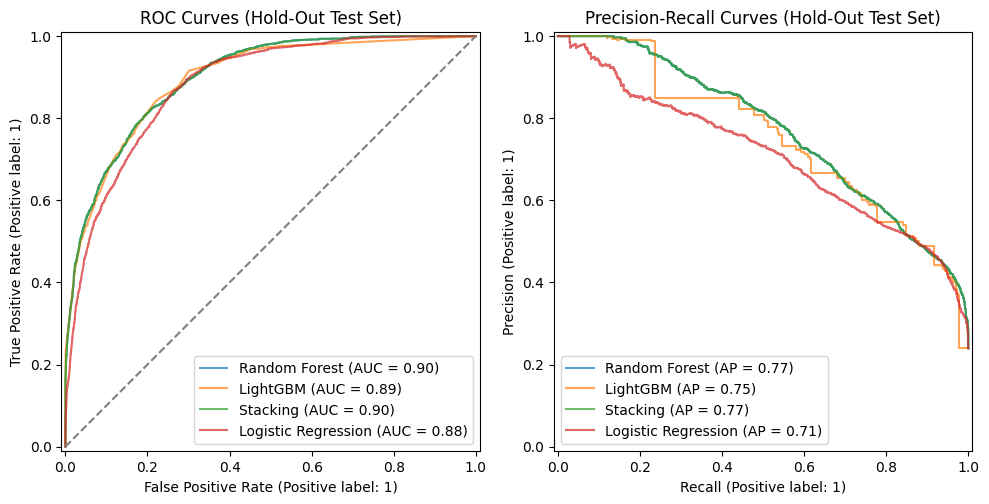

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for name, probs in [
    ("Random Forest", rf_prob),
    ("LightGBM", lgbm_prob),
    ("Stacking", stack_prob),
    ("Logistic Regression", log_prob)
]:
    RocCurveDisplay.from_predictions(
        y_test,
        probs,
        name=name,
        ax=axes[0],
        alpha = 0.7
    )

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probs,
        name=name,
        ax=axes[1],
         alpha=0.7
    )

# Formatting
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_title("ROC Curves (Hold-Out Test Set)")

axes[1].set_title("Precision-Recall Curves (Hold-Out Test Set)")

plt.tight_layout()
plt.show()

**Observation:** All four models land close together on ROC AUC (0.88 to 0.90), so they all rank positives above negatives reasonably well in general. On PR AUC, Random Forest and Stacking are tied at the top (0.77), Logistic Regression trails a bit (0.71), and LightGBM's curve is jagged rather than smooth, which usually means it's working off a smaller number of distinct probability values instead of a continuous range.
These curves matter because they show what each model is capable of across every possible threshold. The metrics table below shows what happens specifically at the default threshold of 0.5, and that's a very different story.

### Final Model Comparison

The tuned **Random Forest** achieved the best overall balance, with the highest Accuracy, Recall, F1-score, ROC AUC, and PR AUC. **LightGBM** had the highest Precision (**98.75%**) while also being faster than Random Forest, making it the best choice when the goal is to avoid false positives.

The **Stacking Ensemble** did not perform as expected. Although it reached **100% Precision**, its Recall dropped to only **2.87%**, meaning it predicted very few positive cases. This resulted in a very low F1-score, showing that the model was too conservative. Since it failed to identify most high-income individuals, stacking did not provide any improvement over the individual models.

Overall, I would either go for **LightGBM** or **Rnadom Forest** as the final model because Precision has been my main evaluation metric throughout this project. It offers the best trade-off between prediction quality, speed, and minimizing false positives.

## Task 2: Class Imbalance
Class imbalance occurs in machine learning when the categories (classes) within a dataset are not represented equally. In a binary classification problem, this means a majority class heavily outnumbers a minority class.

### How imbalanced is this, actually
The Adult Income dataset is imbalanced, with around **76%** of the samples belonging to the **≤50K** class and only **24%** belonging to the **>50K** class. This can make the model favor the majority class and reduce its ability to correctly identify high-income individuals. To address this, three imbalance handling techniques will be compared.

In [77]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

income
0    26751
1     8414
Name: count, dtype: int64
income
0    76.0728
1    23.9272
Name: proportion, dtype: float64


### Pipeline 1
#### Class Weight

Since LightGBM already supports class weights:

In [80]:
class_weight_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        learning_rate=0.01,
        max_depth=3,
        n_estimators=100,
        l2_regularization=1,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

### Pipeline 2

#### Random Oversampling
We need to use oversampling instead of undersampling since our minority lacks data, we need to make up for it

In [82]:
oversample_pipeline = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("classifier", LGBMClassifier(
        learning_rate=0.01,
        max_depth=3,
        n_estimators=100,
        l2_regularization=1,
        random_state=RANDOM_STATE
    ))
])

### Pipeline 3

#### SMOTE

In [83]:
smote_pipeline = ImbPipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LGBMClassifier(
        learning_rate=0.01,
        max_depth=3,
        n_estimators=100,
        l2_regularization=1,
        random_state=RANDOM_STATE
    ))
])

### Cross-validation
I'm going to reuse my CV


In [84]:
scoring = {
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc"
}

In [85]:
cw_cv = cross_validate(
    class_weight_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

ros_cv = cross_validate(
    oversample_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

smote_cv = cross_validate(
    smote_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

### Fit on training data

In [86]:
class_weight_pipeline.fit(X_train,y_train)

oversample_pipeline.fit(X_train,y_train)

smote_pipeline.fit(X_train,y_train)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Info] Number of positive: 8414, number of negative: 26751
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 35165, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...0016548215BC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None


### Evaluating Hold-Out

In [87]:
def evaluate_pipeline(model):

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    return {

        "Precision": precision_score(y_test,pred),
        "Recall": recall_score(y_test,pred),
        "F1": f1_score(y_test,pred),
        "ROC AUC": roc_auc_score(y_test,prob),
        "PR AUC": average_precision_score(y_test,prob)
    }

In [88]:
cw_hold = evaluate_pipeline(class_weight_pipeline)

ros_hold = evaluate_pipeline(oversample_pipeline)

smote_hold = evaluate_pipeline(smote_pipeline)

C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### CV Table

In [89]:
cv_results = pd.DataFrame({

    "Precision":[
        cw_cv["test_precision"].mean(),
        ros_cv["test_precision"].mean(),
        smote_cv["test_precision"].mean()
    ],

    "Recall":[
        cw_cv["test_recall"].mean(),
        ros_cv["test_recall"].mean(),
        smote_cv["test_recall"].mean()
    ],

    "F1":[
        cw_cv["test_f1"].mean(),
        ros_cv["test_f1"].mean(),
        smote_cv["test_f1"].mean()
    ],

    "ROC AUC":[
        cw_cv["test_roc_auc"].mean(),
        ros_cv["test_roc_auc"].mean(),
        smote_cv["test_roc_auc"].mean()
    ]

},
index=[
    "Class Weight",
    "Random Oversampling",
    "SMOTE"
])

cv_results

,Precision,Recall,F1,ROC AUC
Class Weight,0.517154,0.866650,0.647730,0.892767
Random Oversampling,0.515431,0.867719,0.646656,0.893703
SMOTE,0.525218,0.863322,0.653064,0.890471


C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0
[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


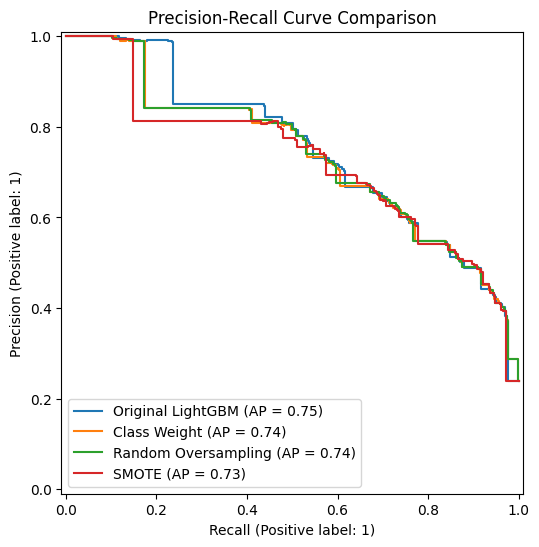

In [92]:
# Initialize the figure and get the current axes
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Original LightGBM (Baseline)
PrecisionRecallDisplay.from_predictions(
    y_test,
    lgbm_pipeline.predict_proba(X_test)[:, 1],
    name="Original LightGBM",
    ax=ax
)

# Class Weight
PrecisionRecallDisplay.from_predictions(
    y_test,
    class_weight_pipeline.predict_proba(X_test)[:, 1],
    name="Class Weight",
    ax=ax
)

# Random Oversampling
PrecisionRecallDisplay.from_predictions(
    y_test,
    oversample_pipeline.predict_proba(X_test)[:, 1],
    name="Random Oversampling",
    ax=ax
)

# SMOTE
PrecisionRecallDisplay.from_predictions(
    y_test,
    smote_pipeline.predict_proba(X_test)[:, 1],
    name="SMOTE",
    ax=ax
)

plt.title("Precision-Recall Curve Comparison")
plt.show()

### Precision-Recall Curve and Metrics Comparison

The Precision-Recall curves for all four approaches are very similar, which shows that handling the class imbalance did not improve the model much. The original LightGBM achieved the highest Average Precision (AP = 0.75), while Class Weight and Random Oversampling both scored 0.74, and SMOTE scored 0.73.

Based on these results, I decided to keep the **original LightGBM**. It gives the best overall precision-recall performance without adding extra complexity, so the imbalance handling techniques were not worth using for this dataset.

### Class Imbalance Results

The imbalance handling techniques increased Recall a lot, with all three methods identifying around **86%** of the high-income individuals. However, this came at the cost of Precision, which dropped from **98.75%** in the original LightGBM model to around **52%**.

The Precision-Recall curves also showed very little improvement over the original model. The original LightGBM achieved the highest Average Precision (AP = 0.75), while Class Weight and Random Oversampling both scored **0.74**, and SMOTE scored **0.73**.

Since the goal of this project is to identify high-income customers for premium product marketing while keeping marketing costs low, I decided to keep the **original LightGBM**. Although the balancing methods found more high-income individuals, they also classified many more low-income customers as positive. This would increase marketing costs by targeting a large number of people who are unlikely to buy the premium products. The original LightGBM remains the better choice because it produces much more reliable positive predictions, making marketing efforts more focused and cost-effective.

## Task 3: Interpretability & Fairness Checks

Using LightGBM (trained on the full engineered feature set) for these checks, since it's my best single ensemble model and tree-based models work well with SHAP's TreeExplainer.
### Global Explanations
### Feature Importances of LightGBM

In [94]:
feature_names = (lgbm_pipeline.named_steps["preprocessor"].get_feature_names_out())

importances = (lgbm_pipeline.named_steps["classifier"].feature_importances_)

importance_df = (pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)
)
importance_df.to_csv("lgbm_feature_importance.csv")
importance_df.head(15)

,Feature,Importance
2,num__capital-gain,285
8,num__edu_hours,165
19,cat__marital-status_Married-civ-spouse,100
1,num__education-num,74
0,num__age,40
3,num__capital-loss,36
4,num__hours-per-week,0
6,num__higher_education,0
5,num__capital_gain_flag,0
9,cat__workclass_Federal-gov,0


### Global Feature Importance
This is a little different from day 3

The model relied the most on **capital-gain**, making it the strongest predictor of high income. The engineered feature **edu_hours** was the second most important feature, showing that combining education and working hours helped the model make better predictions. Other important features included **marital status**, **education level**, **age**, and **capital loss**, which all make sense because they are commonly linked to income.

Some engineered features, such as **capital_gain_flag** and **higher_education**, had little or no importance. This is likely because the original features already captured the same information, so they did not add much to the final model.

### Permutation Importance
Since my final model is lightGBM

In [109]:
perm = permutation_importance(
    lgbm_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="precision",
    n_jobs=-1
)

C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


In [113]:
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    "Importance",
    ascending=False
)

perm_df

,Feature,Importance
8,capital-gain,0.562249
3,marital-status,0.038653
9,capital-loss,0.012412
2,education-num,0.011219
10,hours-per-week,0.003188
1,workclass,0.000000
0,age,0.000000
4,occupation,0.000000
7,sex,0.000000
6,race,0.000000


Permutation importance showed that **capital-gain** had by far the biggest impact on the model's predictions, while **marital-status**, **capital-loss**, **education-num**, and **hours-per-week** had smaller contributions. The remaining features had little to no effect on the model's overall performance.

### SHAP Summary Plot

Need the transformed data.

In [114]:
X_train_processed = lgbm_pipeline.named_steps[
    "preprocessor"
].transform(

    lgbm_pipeline.named_steps[
        "feature_engineering"
    ].transform(X_train)

)

X_test_processed = lgbm_pipeline.named_steps[
    "preprocessor"
].transform(

    lgbm_pipeline.named_steps[
        "feature_engineering"
    ].transform(X_test)

)

In [115]:
model = lgbm_pipeline.named_steps["classifier"]

In [116]:
explainer = shap.TreeExplainer(model)

In [117]:
shap_values = explainer.shap_values(X_test_processed)

C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### Top 8 Features

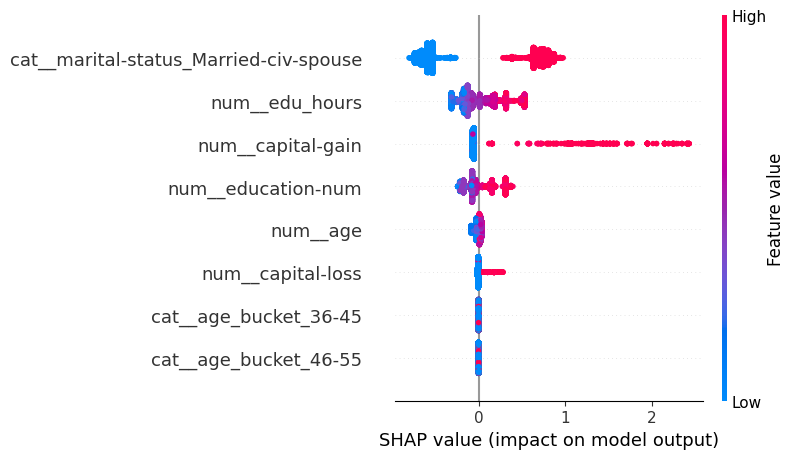

In [118]:
shap.summary_plot(

    shap_values,

    X_test_processed,

    feature_names=feature_names,

    max_display=8
)

**Top 8 features:** looking at the gain importance, permutation importance, and the SHAP summary plot together, the features that keep showing up at the top are things like marital status (being married), capital gain, education level, age, and hours worked. That lines up with everything I found back in the Day 1 EDA and the Day 2/3 coefficients, so it's reassuring that three different ways of measuring "what matters" all agree. The engineered features (`edu_hours`, `log_capital_gain`, `capital_gain_flag`) also show up with real weight, which means the feature engineering from Day 3 was worth doing and not just noise.

### Local explanations
Need TP FP FN

#### Predictions

In [119]:
prob = lgbm_pipeline.predict_proba(X_test)[:,1]

pred = (prob>=0.60).astype(int)

[LightGBM] [Warning] lambda_l2 is set with reg_lambda=0.0, l2_regularization=1 will be ignored. Current value: lambda_l2=0.0


C:\Users\imama\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [162]:
# getting indices
tp = np.where((pred==1)&(y_test==1))[0][0]

fp = np.where((pred==1)&(y_test==0))[0][0]

fn = np.where((pred==0)&(y_test==1))[0][0]

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)


TP: 16
FP: 2290
FN: 4


### Waterfall plot

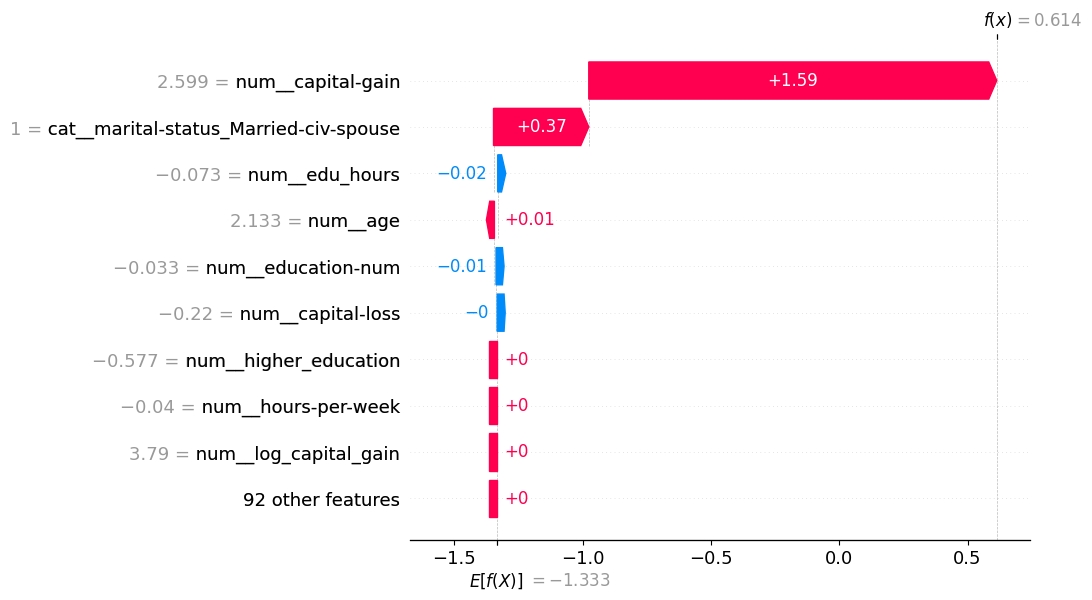

In [163]:
shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[tp],

        base_values=explainer.expected_value,

        data=X_test_processed[tp],

        feature_names=feature_names

    )
)